# v8: PanDerm ViT-Large 皮膚病変7クラス分類

**概要:** PanDerm (Yan et al., Nature Medicine 2025) の事前学習済み ViT-Large を使用し、
HAM10000でLinear Probing → Post-hoc閾値最適化 → Temperature Scalingまで実行。
v3a (DenseNet-121, fine-tuned) と同一のtrain/val splitで評価し、
**基盤モデル (LP) vs CNN (FT)** の定量比較を行う。

**アーキテクチャ:** ViT-Large/16 (embed_dim=1024, depth=24, num_heads=16, ~304M params)
**事前学習:** 2M+皮膚科画像、4モダリティ、11施設、Self-supervised learning
**Downstream:** Linear Probing (backbone凍結 → nn.Linear(1024, 7))

**パイプライン:**
1. PanDerm backbone で特徴抽出（1回のforward pass、backbone凍結）
2. 抽出した1024次元特徴に対してPyTorch nn.Linear(1024, 7) を訓練
3. 以降v5と同一: ROC-AUC → 閾値最適化 → 二値集約 → Temperature Scaling

**参考文献:**
- Yan et al., Nature Medicine (2025): PanDerm
- Esteva et al., Nature 542 (2017): 二値集約の根拠
- Guo et al., ICML 2017: Temperature Scaling

In [1]:
import random
import torch
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

### ライブラリ読み込み

In [2]:
%matplotlib inline
import os, cv2, itertools, time, copy, json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image
from pathlib import Path
from datetime import datetime
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from torchvision import transforms

import timm

from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, auc, precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

print(os.listdir('../data'))

Device: cuda:0
  GPU 0: NVIDIA GeForce RTX 3080
  GPU 1: NVIDIA GeForce RTX 3080
['HAM10000_images_part_2', 'DDI', 'HAM10000_images_part_1', 'fitzpatrick17k', 'HAM10000_metadata.csv']


## 1. データ前処理（v5と同一）

In [3]:
# ============================================================
# データ読み込み・クラス定義（v5 Cell 6, 12 と同一）
# ============================================================
data_dir = '../data'
all_image_path = glob(os.path.join(data_dir, '*', '*.jpg'))
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in all_image_path}

lesion_type_dict = {
    'nv': 'Melanocytic nevi', 'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions', 'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses', 'vasc': 'Vascular lesions', 'df': 'Dermatofibroma'
}

dx_to_idx = {
    'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6,
}

df_original = pd.read_csv(os.path.join(data_dir, 'HAM10000_metadata.csv'))
df_original['path'] = df_original['image_id'].map(imageid_path_dict.get)
df_original['cell_type'] = df_original['dx'].map(lesion_type_dict.get)
df_original['cell_type_idx'] = df_original['dx'].map(dx_to_idx)
print(f'Total images: {len(df_original)}')
df_original.head()

Total images: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0027419.jpg,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025030.jpg,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0026769.jpg,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../data/HAM10000_images_part_1/ISIC_0025661.jpg,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../data/HAM10000_images_part_2/ISIC_0031633.jpg,Benign keratosis-like lesions,2


In [4]:
# ============================================================
# 3分割: train / val / test（v3aと同一分割、random_state=42）
# ============================================================

# 重複なしlesion_idを抽出
df_undup = df_original.groupby('lesion_id').count()
df_undup = df_undup[df_undup['image_id'] == 1]
df_undup.reset_index(inplace=True)

def get_duplicates(x):
    unique_list = list(df_undup['lesion_id'])
    return 'unduplicated' if x in unique_list else 'duplicated'

df_original['duplicates'] = df_original['lesion_id'].apply(get_duplicates)
df_undup_full = df_original[df_original['duplicates'] == 'unduplicated']

y = df_undup_full['cell_type_idx']
df_train_undup, df_valtest = train_test_split(
    df_undup_full, test_size=0.2, random_state=42, stratify=y
)
df_val, df_test = train_test_split(
    df_valtest, test_size=0.5, random_state=42,
    stratify=df_valtest['cell_type_idx']
)

val_ids = set(df_val['image_id'])
test_ids = set(df_test['image_id'])
df_train = df_original[
    ~df_original['image_id'].isin(val_ids | test_ids)
]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f'Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}')
print(f'Total: {len(df_train) + len(df_val) + len(df_test)} (original: {len(df_original)})')


Train: 8912, Val: 551, Test: 552
Total: 10015 (original: 10015)


## 2. PanDermモデル構築

PanDerm ViT-Large をtimm経由でロード。`num_classes=0` で分類ヘッドなし（特徴抽出器モード）。
出力は1024次元の特徴ベクトル。

**Normalize:** ImageNet標準値 `(0.485, 0.456, 0.406)` / `(0.228, 0.224, 0.225)`
（v5のHAM10000 train split値とは異なる。PanDermはImageNet normで事前学習されているため）

In [5]:
# ============================================================
# PanDerm ViT-Large ロード（PanDerm自前のVisionTransformerクラスを使用）
# ============================================================
import sys, importlib.util
import warnings
warnings.filterwarnings("ignore", message="Overwriting.*in registry")
warnings.filterwarnings("ignore", category=FutureWarning, module="timm")
warnings.filterwarnings("ignore", message="torch.meshgrid")

# PanDermのmodeling_finetune.pyを直接ロード（open_clip依存を回避）
spec = importlib.util.spec_from_file_location(
    "modeling_finetune",
    os.path.expanduser("~/PanDerm/classification/models/modeling_finetune.py")
)
mf = importlib.util.module_from_spec(spec)
sys.modules["modeling_finetune"] = mf
spec.loader.exec_module(mf)

CKPT_PATH = os.path.expanduser('~/PanDerm/checkpoints/panderm_ll_data6_checkpoint-499.pth')
assert os.path.isfile(CKPT_PATH), f'Checkpoint not found: {CKPT_PATH}'

model_backbone = mf.panderm_large_patch16_224()
state_dict = torch.load(CKPT_PATH, map_location='cpu', weights_only=True)
state_dict = {k.replace("encoder.", ""): v for k, v in state_dict.items()}
missing, unexpected = model_backbone.load_state_dict(state_dict, strict=False)

# 分類ヘッドを除去（特徴ベクトルのみ出力）
model_backbone.head = nn.Identity()

print(f'PanDerm ViT-Large loaded')
print(f'  Missing keys: {len(missing)} (head only — expected)')
print(f'  Unexpected keys: {len(unexpected)} (decoder/regresser — not needed)')

model_backbone = model_backbone.to(device)
model_backbone.eval()

# 出力次元確認
with torch.no_grad():
    test_input = torch.randn(1, 3, 224, 224).to(device)
    test_output = model_backbone(test_input)
    EMBED_DIM = test_output.shape[1]
    print(f'  Embedding dim: {EMBED_DIM}')
del test_input, test_output

PanDerm ViT-Large loaded
  Missing keys: 2 (head only — expected)
  Unexpected keys: 92 (decoder/regresser — not needed)
  Embedding dim: 1024


In [6]:
# ============================================================
# Transform定義（PanDermの事前学習時と同じImageNet normalization）
# ============================================================
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.228, 0.224, 0.225)

# 特徴抽出用（augmentationなし、deterministic）
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(f'eval_transform: {eval_transform}')

eval_transform: Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.228, 0.224, 0.225))
)


## 3. Linear Probing（特徴抽出 → nn.Linear訓練）

**ステップ:**
1. PanDerm backbone（凍結）で全画像の特徴ベクトルを抽出（1回のforward pass）
2. 抽出した1024次元特徴に対して `nn.Linear(1024, 7)` を訓練
3. logitsを取得 → 以降のpost-hoc・calibrationパイプラインに接続

**なぜPyTorchのnn.Linearか？**（sklearnではなく）
- logitsが直接取得できる → Temperature Scalingにそのまま使える
- v5と同じ `.npz` 保存フォーマット（all_probs, all_logits, y_true）で統一

In [7]:
# ============================================================
# HAM10000 Dataset（v5と同一構造、transformのみ変更）
# ============================================================
class HAM10000(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        with Image.open(row['path']) as img:
            X = img.convert('RGB').copy()
        if self.transform:
            X = self.transform(X)
        y = row['cell_type_idx']
        return X, y

# DataLoader（特徴抽出用、shuffle不要）
train_dataset = HAM10000(df_train, transform=eval_transform)
val_dataset = HAM10000(df_val, transform=eval_transform)

# 特徴抽出はbatch_size大きめ（推論のみ、勾配不要）
train_feat_loader = DataLoader(train_dataset, batch_size=128, shuffle=False, num_workers=4)
val_feat_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)

# Test set
test_dataset = HAM10000(df_test, transform=eval_transform)
test_feat_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 8912, Val: 551, Test: 552


In [8]:
# ============================================================
# 特徴抽出（PanDerm backbone → 1024次元 embedding）
# ============================================================
def extract_features(model, dataloader, device):
    """Frozen backboneで全画像の特徴ベクトルを抽出。"""
    all_feats = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Extracting features'):
            images = images.to(device)
            features = model(images)  # (B, 1024)
            all_feats.append(features.cpu())
            all_labels.append(labels)
    return torch.cat(all_feats, dim=0), torch.cat(all_labels, dim=0)

start = time.time()
train_feats, train_labels = extract_features(model_backbone, train_feat_loader, device)
val_feats, val_labels = extract_features(model_backbone, val_feat_loader, device)
test_feats, test_labels = extract_features(model_backbone, test_feat_loader, device)
elapsed = time.time() - start

print(f'Feature extraction: {elapsed:.1f}s')
print(f'Train features: {train_feats.shape}')
print(f'Val features:   {val_feats.shape}')
print(f'Test features:  {test_feats.shape}')

# backboneはもう不要 → VRAM解放
del model_backbone
torch.cuda.empty_cache()
print('Backbone released from GPU')


Extracting features: 100%|██████████████████████████| 5/5 [00:06<00:00,  1.25s/it]

Feature extraction: 93.2s
Train features: torch.Size([8912, 1024])
Val features:   torch.Size([551, 1024])
Test features:  torch.Size([552, 1024])
Backbone released from GPU


In [9]:
# ============================================================
# Linear Probing: sklearn LogisticRegression (著者実装に準拠)
# ============================================================
# PanDerm論文の実装:
#   solver=lbfgs, λ=MC/100, max_iter=1000
#   M=embedding dim(1024), C=num_classes(7)
#   sklearn C = 1/λ = 100/(M*C)
from sklearn.linear_model import LogisticRegression
import torch.nn.functional as F

EMBED_DIM = 1024
NUM_CLASSES = 7

# λ = MC/100, C_sklearn = 1/λ
lam = EMBED_DIM * NUM_CLASSES / 100   # = 71.68
C_sklearn = 1.0 / lam                 # ≈ 0.01395

print(f'LP: sklearn LogisticRegression (著者実装準拠)')
print(f'  λ = M*C/100 = {EMBED_DIM}*{NUM_CLASSES}/100 = {lam:.2f}')
print(f'  C (sklearn) = 1/λ = {C_sklearn:.5f}')
print(f'  solver=lbfgs, max_iter=1000')

# CPU numpy配列に変換（sklearnはGPU不要）
X_train = train_feats.numpy()
y_train = train_labels.numpy()
X_val   = val_feats.numpy()
y_val   = val_labels.numpy()

clf = LogisticRegression(
    C=C_sklearn,
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    verbose=0,
)
clf.fit(X_train, y_train)

val_acc = clf.score(X_val, y_val)
print(f'\nVal accuracy: {val_acc:.4f}')

# 以降のセルとの互換性のため、val推論結果をnumpy/torchで保持
y_true      = y_val
all_probs   = clf.predict_proba(X_val)          # (N, 7) numpy
y_pred      = all_probs.argmax(axis=1)

# val用GPU tensorも残す（後続セルで使う場合）
val_feats_gpu  = val_feats.to(device)
val_labels_gpu = val_labels.to(device)

# linear_headをsklearnの重みからnn.Linearに変換（v9headロード用）
linear_head = nn.Linear(EMBED_DIM, NUM_CLASSES)
linear_head.weight.data = torch.tensor(clf.coef_, dtype=torch.float32)
linear_head.bias.data   = torch.tensor(clf.intercept_, dtype=torch.float32)
linear_head = linear_head.to(device)
linear_head.eval()

print(f'linear_head (nn.Linear) 変換完了 — v9との互換性を維持')

LP: sklearn LogisticRegression (著者実装準拠)
  λ = M*C/100 = 1024*7/100 = 71.68
  C (sklearn) = 1/λ = 0.01395
  solver=lbfgs, max_iter=1000

Val accuracy: 0.9183
linear_head (nn.Linear) 変換完了 — v9との互換性を維持


## 4. 評価

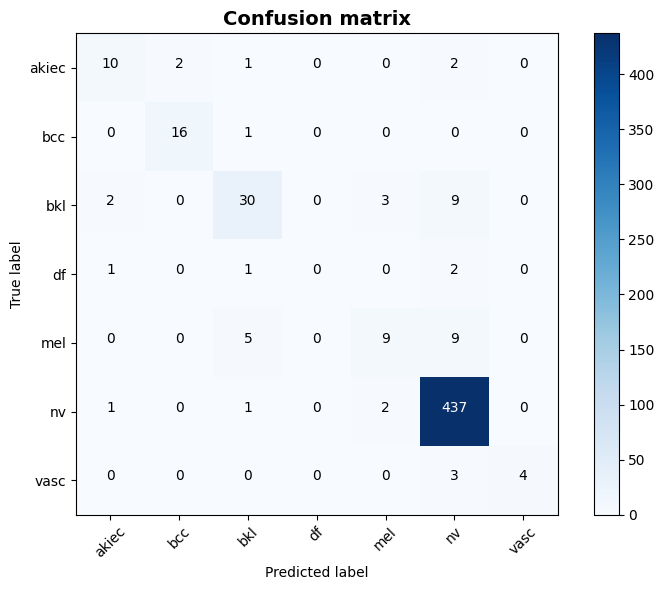

              precision    recall  f1-score   support

       akiec       0.71      0.67      0.69        15
         bcc       0.89      0.94      0.91        17
         bkl       0.77      0.68      0.72        44
          df       0.00      0.00      0.00         4
         mel       0.64      0.39      0.49        23
          nv       0.95      0.99      0.97       441
        vasc       1.00      0.57      0.73         7

    accuracy                           0.92       551
   macro avg       0.71      0.61      0.64       551
weighted avg       0.90      0.92      0.91       551

ROC-AUC (macro, OvR): 0.9729
  akiec: 0.9791
  bcc: 0.9991
  bkl: 0.9679
  df: 0.9374
  mel: 0.9406
  nv: 0.9872
  vasc: 0.9992

 TEST SET EVALUATION


/home/komai/miniconda3/envs/skin-ai/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/komai/miniconda3/envs/skin-ai/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/komai/miniconda3/envs/skin-ai/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

<Figure size 800x600 with 0 Axes>

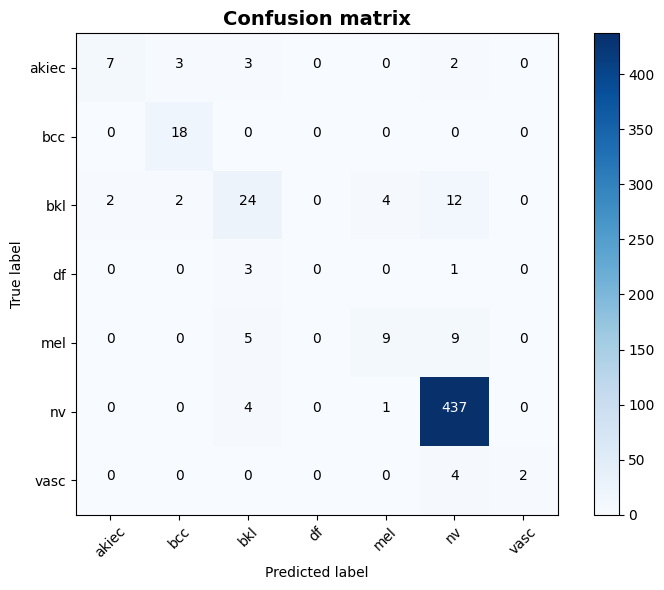

              precision    recall  f1-score   support

       akiec       0.78      0.47      0.58        15
         bcc       0.78      1.00      0.88        18
         bkl       0.62      0.55      0.58        44
          df       0.00      0.00      0.00         4
         mel       0.64      0.39      0.49        23
          nv       0.94      0.99      0.96       442
        vasc       1.00      0.33      0.50         6

    accuracy                           0.90       552
   macro avg       0.68      0.53      0.57       552
weighted avg       0.89      0.90      0.89       552

Test ROC-AUC (macro, OvR): 0.9862
  akiec: 0.9856
  bcc: 0.9986
  bkl: 0.9686
  df: 1.0000
  mel: 0.9682
  nv: 0.9852
  vasc: 0.9969


/home/komai/miniconda3/envs/skin-ai/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/komai/miniconda3/envs/skin-ai/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/komai/miniconda3/envs/skin-ai/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [10]:
# ============================================================
# 評価: ROC-AUC, Classification Report, Confusion Matrix
# ============================================================
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
NUM_CLASSES = 7
MEL_IDX = CLASS_NAMES.index('mel')
MALIGNANT_INDICES = [CLASS_NAMES.index(c) for c in ['mel', 'bcc', 'akiec']]
BENIGN_INDICES = [CLASS_NAMES.index(c) for c in ['nv', 'bkl', 'df', 'vasc']]

# 推論
linear_head.eval()
with torch.no_grad():
    val_logits = linear_head(val_feats_gpu)
    val_probs = F.softmax(val_logits, dim=1)

y_true = val_labels.numpy()
y_pred = val_logits.argmax(1).cpu().numpy()
y_prob = val_probs.cpu().numpy()
all_logits_np = val_logits.cpu().numpy()
all_probs = y_prob

y_true_onehot = label_binarize(y_true, classes=range(7))

# ---- Confusion Matrix ----
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

confusion_mtx = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(confusion_mtx, CLASS_NAMES)
plt.show()

# ---- Classification Report ----
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ---- ROC-AUC ----
roc_auc = roc_auc_score(y_true_onehot, y_prob, multi_class='ovr', average='macro')
print(f"ROC-AUC (macro, OvR): {roc_auc:.4f}")
for i, name in enumerate(CLASS_NAMES):
    auc_i = roc_auc_score(y_true_onehot[:, i], y_prob[:, i])
    print(f"  {name}: {auc_i:.4f}")
# --- Test評価（最終報告用） ---
test_feats_gpu = test_feats.to(device)
with torch.no_grad():
    test_logits_out = linear_head(test_feats_gpu)
    test_probs_out = F.softmax(test_logits_out, dim=1)

y_true_test = test_labels.numpy()
y_pred_test = test_logits_out.argmax(1).cpu().numpy()
y_prob_test = test_probs_out.cpu().numpy()
test_logits_np = test_logits_out.cpu().numpy()

y_true_test_onehot = label_binarize(y_true_test, classes=range(7))
confusion_mtx_test = confusion_matrix(y_true_test, y_pred_test)

print(f'\n{"="*60}')
print(' TEST SET EVALUATION')
print(f'{"="*60}')
plt.figure(figsize=(8, 6))
plot_confusion_matrix(confusion_mtx_test, CLASS_NAMES)
plt.show()
print(classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES))

roc_auc_test = roc_auc_score(y_true_test_onehot, y_prob_test, multi_class='ovr', average='macro')
print(f"Test ROC-AUC (macro, OvR): {roc_auc_test:.4f}")
for i, name in enumerate(CLASS_NAMES):
    auc_i = roc_auc_score(y_true_test_onehot[:, i], y_prob_test[:, i])
    print(f"  {name}: {auc_i:.4f}")


### 成果物保存

In [11]:
# ============================================================
# モデル保存 + val/test推論結果保存（both raw）
# ============================================================
os.makedirs('../models', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)
V8_DIR = Path('../results/v8'); V8_DIR.mkdir(parents=True, exist_ok=True)

NB_NAME = 'v8'
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Linear head のみ保存
head_save_path = f'../models/panderm_lp_head_v8_{timestamp}.pth'
torch.save(linear_head.state_dict(), head_save_path)
print(f'Linear head saved: {head_save_path}')

# val npz (raw)
val_npz_path = f'../results/models/{NB_NAME}_val_predictions.npz'
np.savez(val_npz_path,
    all_probs=all_probs, y_true=y_true, all_logits=all_logits_np)
print(f'Val npz saved: {val_npz_path}')

# test npz (raw)
test_npz_path = f'../results/models/{NB_NAME}_test_predictions.npz'
np.savez(test_npz_path,
    all_probs=y_prob_test, y_true=y_true_test, all_logits=test_logits_np)
print(f'Test npz saved: {test_npz_path}')


Linear head saved: ../models/panderm_lp_head_v8_20260311_184753.pth
Val npz saved: ../results/models/v8_val_predictions.npz
Test npz saved: ../results/models/v8_test_predictions.npz


## 5. Model Calibration — Temperature Scaling

**TSを先に行う理由:**
malignant 3クラスの確率をsumする集約では `sum(softmax(z/T))` が
`sum(softmax(z))` の単調変換にならない。
未較正probsで決めた閾値はTS後に最適でなくなる可能性があるため、
閾値最適化の前にTSを適用する。


In [12]:
# ============================================================
# D. Calibration 関数定義 — v5 Cell 58 と同一
# ============================================================

def compute_ece(probs, labels, n_bins=15):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == labels).astype(float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_accs = np.zeros(n_bins)
    bin_confs = np.zeros(n_bins)
    bin_counts = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences >= lo) & (confidences <= hi if i == n_bins - 1 else confidences < hi)
        bin_counts[i] = mask.sum()
        if bin_counts[i] > 0:
            bin_accs[i] = accuracies[mask].mean()
            bin_confs[i] = confidences[mask].mean()
    ece = np.sum(bin_counts / len(labels) * np.abs(bin_accs - bin_confs))
    return ece, {'bin_edges': bin_edges, 'bin_accs': bin_accs, 'bin_confs': bin_confs, 'bin_counts': bin_counts}

def plot_reliability_diagram(bin_data, ece, title='Reliability Diagram', save_path=None):
    n_bins = len(bin_data['bin_accs'])
    centers = (bin_data['bin_edges'][:-1] + bin_data['bin_edges'][1:]) / 2
    w = bin_data['bin_edges'][1] - bin_data['bin_edges'][0]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    ax1.bar(centers, bin_data['bin_accs'], width=w*0.85, color='#3498db', edgecolor='#2c3e50', alpha=0.85, label='Actual accuracy')
    for i in range(n_bins):
        if bin_data['bin_counts'][i] > 0:
            gap = bin_data['bin_confs'][i] - bin_data['bin_accs'][i]
            if abs(gap) > 0.01:
                c = '#e74c3c' if gap > 0 else '#2ecc71'
                ax1.bar(centers[i], abs(gap), width=w*0.85,
                        bottom=min(bin_data['bin_accs'][i], bin_data['bin_confs'][i]), color=c, alpha=0.35)
    ax1.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect')
    ax1.set_ylabel('Actual accuracy', fontsize=13)
    ax1.set_title(f'{title}\nECE = {ece:.4f}', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left'); ax1.set_xlim(0,1); ax1.set_ylim(0,1); ax1.grid(True, alpha=0.3)
    ax2.bar(centers, bin_data['bin_counts'], width=w*0.85, color='#95a5a6', edgecolor='#2c3e50', linewidth=0.5)
    ax2.set_xlabel('Model output', fontsize=13); ax2.set_ylabel('Count', fontsize=13)
    ax2.set_xlim(0,1); ax2.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def fit_temperature(logits_np, labels_np):
    logits_t = torch.from_numpy(logits_np).float()
    labels_t = torch.from_numpy(labels_np).long()
    temperature = nn.Parameter(torch.ones(1))
    nll = nn.CrossEntropyLoss()
    optimizer_ts = optim.LBFGS([temperature], lr=0.01, max_iter=1000)
    def closure():
        optimizer_ts.zero_grad()
        loss = nll(logits_t / temperature, labels_t)
        loss.backward()
        return loss
    optimizer_ts.step(closure)
    T = temperature.item()
    with torch.no_grad():
        nll_before = nll(logits_t, labels_t).item()
        nll_after = nll(logits_t / temperature, labels_t).item()
    print(f"  T = {T:.4f}")
    print(f"  NLL: {nll_before:.4f} → {nll_after:.4f}")
    return T

def apply_temperature(logits_np, T):
    scaled = torch.from_numpy(logits_np).float() / T
    return torch.softmax(scaled, dim=1).numpy()

print("Calibration functions defined ✓")

Calibration functions defined ✓


D. Model Calibration — PanDerm LP

── Before ──
  ECE = 0.0544


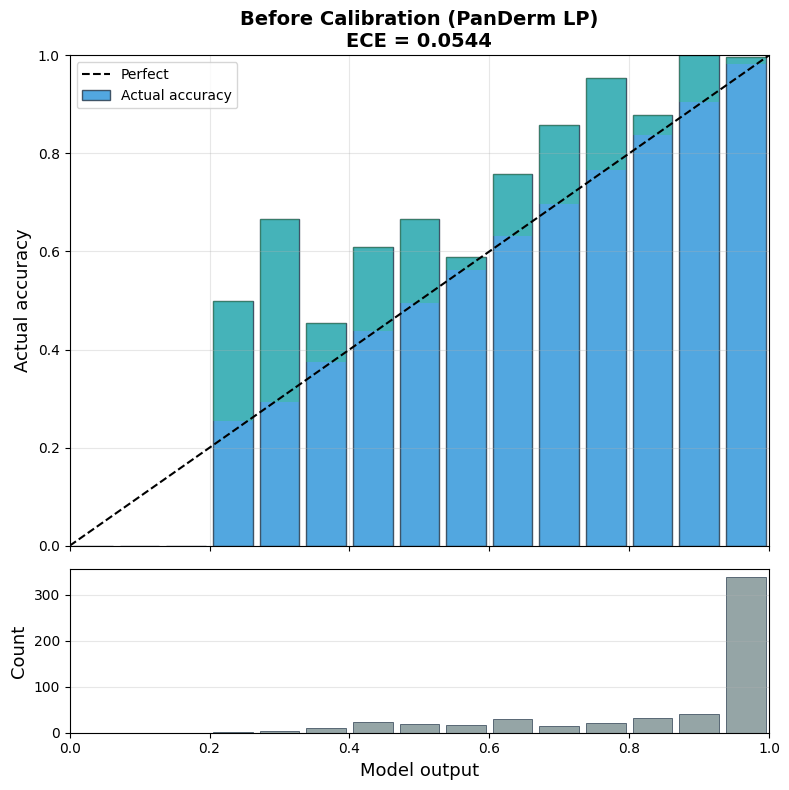


── Temperature Scaling ──
  T = 0.7301
  NLL: 0.2853 → 0.2661

── After ──
  ECE = 0.0347
  改善: 0.0544 → 0.0347 (Δ=-0.0196)


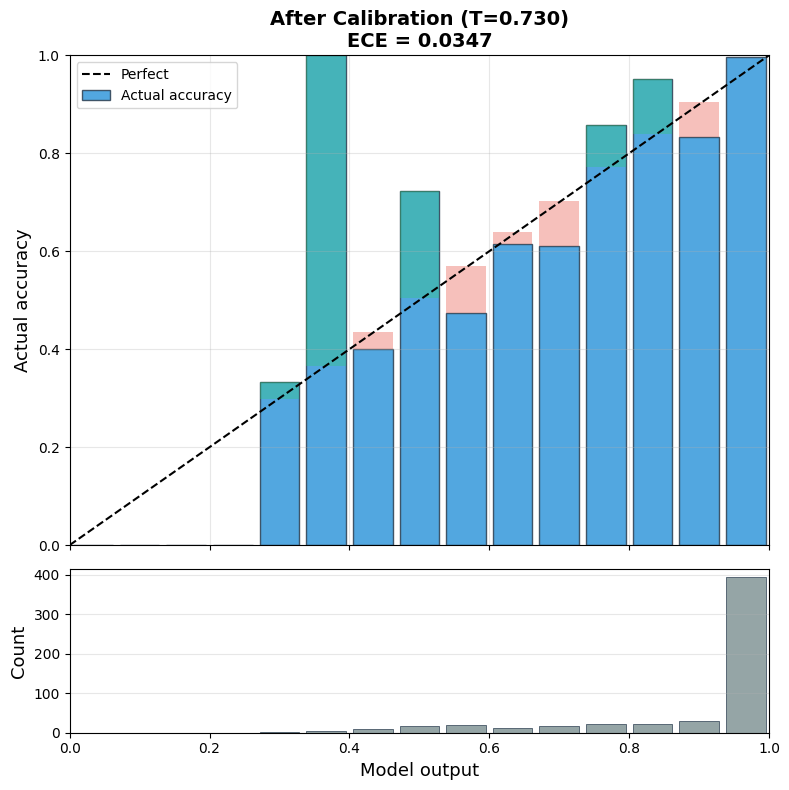

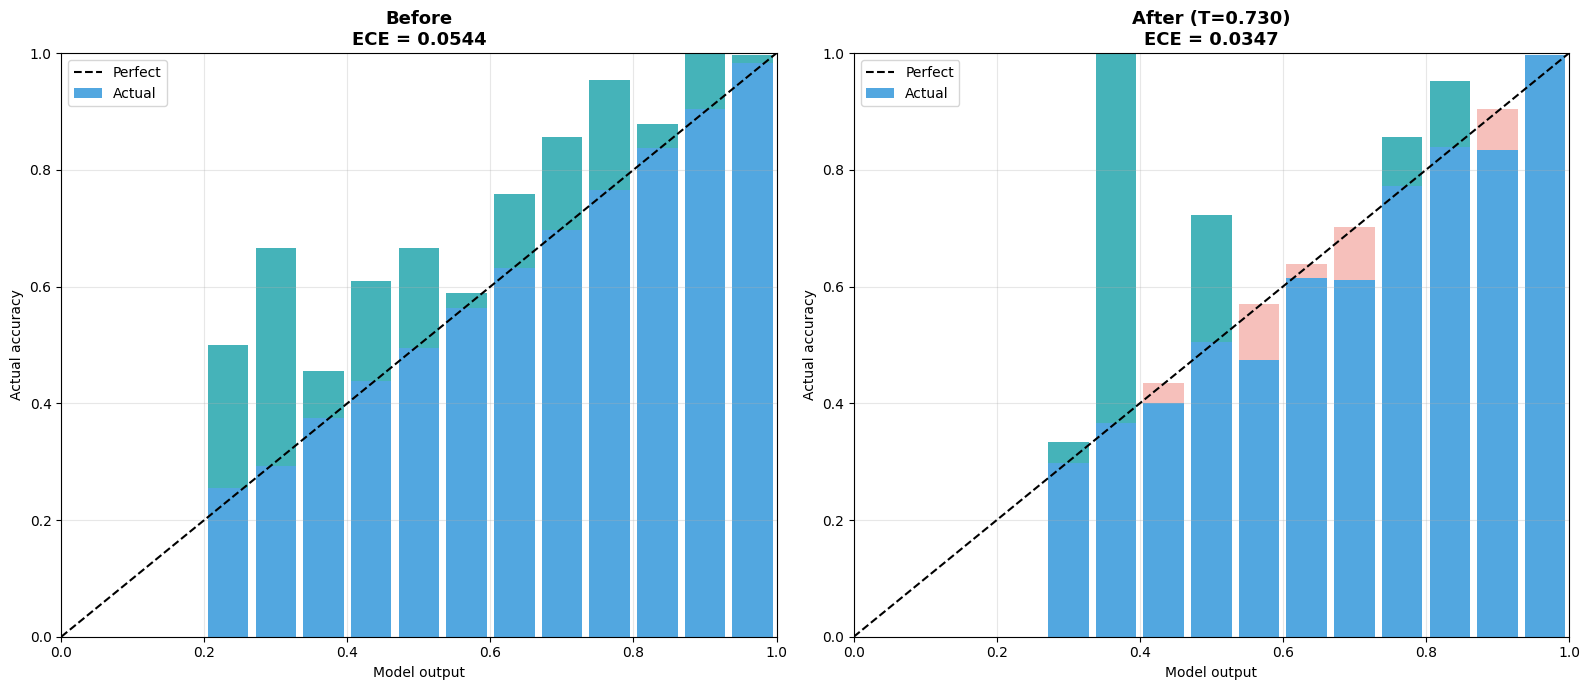

Saved: ../results/v8/temperature_v8.json
all_probs → TS補正済み（メモリ上のみ、npzは書き換えない） ✓


In [13]:
# ============================================================
# D. Calibration 実行 — v5 Cell 59 と同一
# ============================================================
V8_DIR = Path("../results/v8")
V8_DIR.mkdir(parents=True, exist_ok=True)
NB_NAME = 'v8'

print("=" * 60)
print("D. Model Calibration — PanDerm LP")
print("=" * 60)

# Before
print("\n── Before ──")
ece_before, bd_before = compute_ece(all_probs, y_true)
print(f"  ECE = {ece_before:.4f}")
plot_reliability_diagram(bd_before, ece_before, 'Before Calibration (PanDerm LP)',
    V8_DIR / 'fig_d3_reliability_before.png')

# Temperature Scaling
print("\n── Temperature Scaling ──")
T = fit_temperature(all_logits_np, y_true)
probs_calibrated = apply_temperature(all_logits_np, T)

# After
print("\n── After ──")
ece_after, bd_after = compute_ece(probs_calibrated, y_true)
print(f"  ECE = {ece_after:.4f}")
print(f"  改善: {ece_before:.4f} → {ece_after:.4f} (Δ={ece_after-ece_before:+.4f})")
plot_reliability_diagram(bd_after, ece_after, f'After Calibration (T={T:.3f})',
    V8_DIR / 'fig_d5_reliability_after.png')

# Before/After 比較
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, bd, ece, title in [
    (axes[0], bd_before, ece_before, 'Before'),
    (axes[1], bd_after, ece_after, f'After (T={T:.3f})'),
]:
    centers = (bd['bin_edges'][:-1] + bd['bin_edges'][1:]) / 2
    w = bd['bin_edges'][1] - bd['bin_edges'][0]
    ax.bar(centers, bd['bin_accs'], width=w*0.85, color='#3498db', alpha=0.85, label='Actual')
    ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect')
    for i in range(len(bd['bin_accs'])):
        if bd['bin_counts'][i] > 0:
            gap = bd['bin_confs'][i] - bd['bin_accs'][i]
            if abs(gap) > 0.01:
                c = '#e74c3c' if gap > 0 else '#2ecc71'
                ax.bar(centers[i], abs(gap), width=w*0.85,
                       bottom=min(bd['bin_accs'][i], bd['bin_confs'][i]), color=c, alpha=0.35)
    ax.set_title(f'{title}\nECE = {ece:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Model output'); ax.set_ylabel('Actual accuracy')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(V8_DIR / 'fig_d5_reliability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# T保存
with open(V8_DIR / 'temperature_v8.json', 'w') as f:
    json.dump({'temperature': T, 'ece_before': float(ece_before), 'ece_after': float(ece_after), 'model': NB_NAME}, f, indent=2)
print(f'Saved: {V8_DIR}/temperature_v8.json')
# post-hocセクション用にTS後probsをall_probsとして設定
all_probs = probs_calibrated
print('all_probs → TS補正済み（メモリ上のみ、npzは書き換えない） ✓')


## 6. Post-hoc 閾値最適化・良悪性二値集約

post-hocセクション以降は保存済み推論結果(.npz)から復元して実行可能。GPU不要。
モデルの重みは変えず、判定ルール（閾値・二値集約）を最適化する。

In [14]:
# ============================================================
# Cell 1: 共通準備 — 保存済み結果から復元（GPU不要・ここから実行可）
# ============================================================
RESULTS_DIR = Path("../results/models")
RESULTS_DIR.mkdir(exist_ok=True)
CALIB_DIR = Path("../results/calibration")
CALIB_DIR.mkdir(exist_ok=True)

# v8固有: 結果ディレクトリ
V8_DIR = Path("../results/v8")
V8_DIR.mkdir(exist_ok=True)

NB_NAME = 'v8'

# 保存済みから復元する場合はここをアンコメント:
# _data = np.load(RESULTS_DIR / f"{NB_NAME}_val_predictions.npz")
# all_probs = _data["all_probs"]
# y_true = _data["y_true"]
# all_logits_np = _data["all_logits"]

y_true_onehot = np.eye(NUM_CLASSES)[y_true]
N = len(y_true)

print(f"Validation samples: {N}")
print(f"Class distribution: {dict(zip(CLASS_NAMES, np.bincount(y_true, minlength=NUM_CLASSES)))}") 
# TS適用済みprobsを使用（メモリ上のみ、npz未変更）
all_probs = probs_calibrated
print('all_probs → TS補正済み（メモリ上のみ） ✓')


Validation samples: 551
Class distribution: {'akiec': np.int64(15), 'bcc': np.int64(17), 'bkl': np.int64(44), 'df': np.int64(4), 'mel': np.int64(23), 'nv': np.int64(441), 'vasc': np.int64(7)}
all_probs → TS補正済み（メモリ上のみ） ✓


A-6: Per-class OvR Threshold Optimization


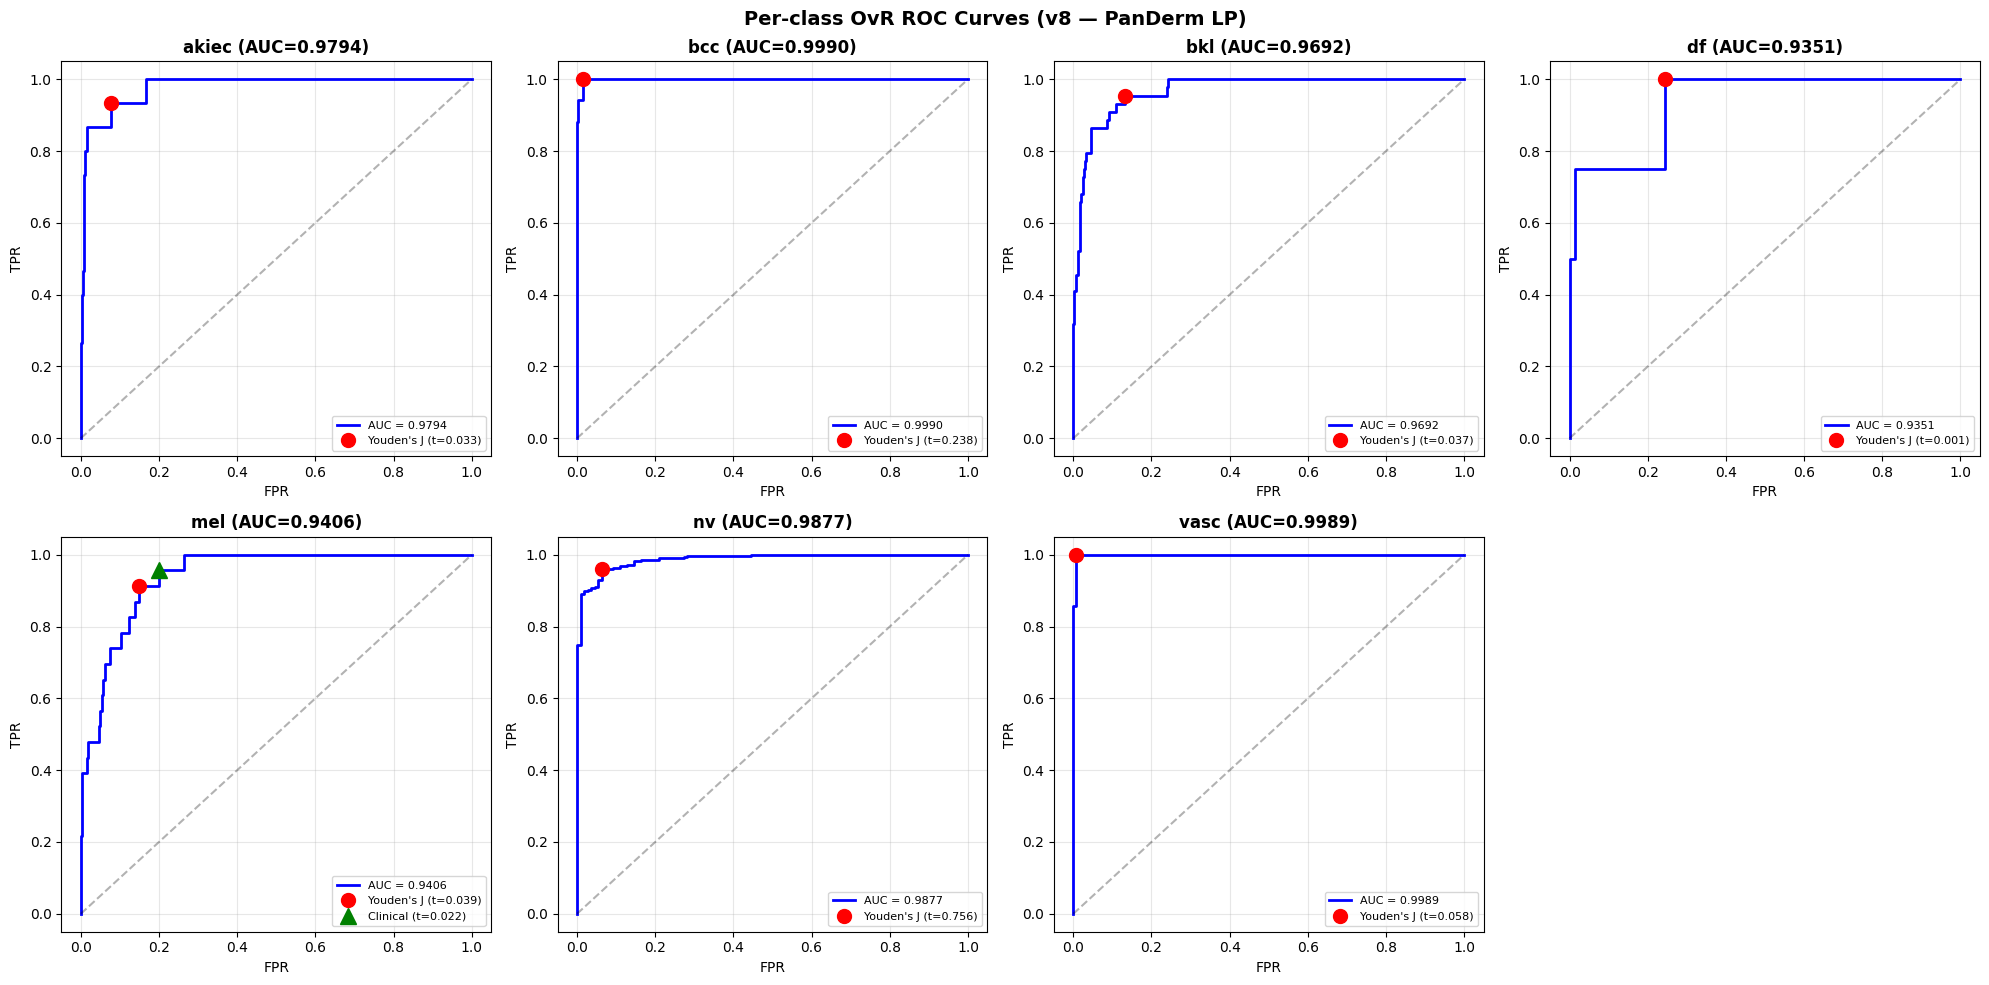


Class     Threshold  Sensitivity  Specificity   Youden J
-------------------------------------------------------
akiec        0.0325       0.9333       0.9235     0.8568
bcc          0.2378       1.0000       0.9850     0.9850
bkl          0.0365       0.9545       0.8679     0.8224
df           0.0013       1.0000       0.7569     0.7569
mel          0.0390       0.9130       0.8523     0.7653
nv           0.7562       0.9592       0.9364     0.8955
vasc         0.0581       1.0000       0.9926     0.9926

Clinical (mel ≧95%): threshold=0.0222, sens=0.9565, spec=0.7992

Youden threshold classification (fallback: 0/551):
              precision    recall  f1-score   support

       akiec      0.667     0.667     0.667        15
         bcc      0.800     0.941     0.865        17
         bkl      0.706     0.818     0.758        44
          df      0.000     0.000     0.000         4
         mel      0.429     0.522     0.471        23
          nv      0.984     0.959     0.971  

In [15]:
# ============================================================
# A-6: 閾値最適化（7クラス OvR） — v5 Cell 53 と同一ロジック
# ============================================================
print("=" * 70)
print("A-6: Per-class OvR Threshold Optimization")
print("=" * 70)

thresholds_youden = {}
thresholds_clinical = {}
roc_data = {}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, cls_name in enumerate(CLASS_NAMES):
    fpr, tpr, thresholds = roc_curve(y_true_onehot[:, i], all_probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    roc_data[cls_name] = {'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds, 'auc': roc_auc_val}

    j_scores = tpr - fpr
    best_j_idx = j_scores.argmax()
    best_threshold = thresholds[best_j_idx]
    thresholds_youden[cls_name] = {
        'threshold': best_threshold,
        'sensitivity': tpr[best_j_idx],
        'specificity': 1 - fpr[best_j_idx],
        'youden_j': j_scores[best_j_idx]
    }

    if cls_name == 'mel':
        clinical_candidates = np.where(tpr >= 0.95)[0]
        if len(clinical_candidates) > 0:
            best_clinical_idx = clinical_candidates[np.argmin(fpr[clinical_candidates])]
            thresholds_clinical['mel'] = {
                'threshold': thresholds[best_clinical_idx],
                'sensitivity': tpr[best_clinical_idx],
                'specificity': 1 - fpr[best_clinical_idx]
            }
        else:
            thresholds_clinical['mel'] = {'threshold': 0.0, 'sensitivity': 1.0, 'specificity': 0.0}
            print("  WARNING: mel sensitivity >= 95% not achievable!")

    ax = axes[i]
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc_val:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.plot(fpr[best_j_idx], tpr[best_j_idx], 'ro', markersize=10,
            label=f"Youden's J (t={best_threshold:.3f})")
    if cls_name == 'mel' and len(clinical_candidates) > 0:
        ax.plot(fpr[best_clinical_idx], tpr[best_clinical_idx], 'g^', markersize=12,
                label=f'Clinical (t={thresholds_clinical["mel"]["threshold"]:.3f})')
    ax.set_title(f'{cls_name} (AUC={roc_auc_val:.4f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)

axes[7].axis('off')
plt.suptitle(f"Per-class OvR ROC Curves ({NB_NAME} — PanDerm LP)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(V8_DIR / 'fig_a6_ovr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# サマリー
print(f"\n{'Class':<8} {'Threshold':>10} {'Sensitivity':>12} {'Specificity':>12} {'Youden J':>10}")
print("-" * 55)
for cls_name in CLASS_NAMES:
    t = thresholds_youden[cls_name]
    print(f"{cls_name:<8} {t['threshold']:>10.4f} {t['sensitivity']:>12.4f} {t['specificity']:>12.4f} {t['youden_j']:>10.4f}")
tc = thresholds_clinical['mel']
print(f"\nClinical (mel ≧95%): threshold={tc['threshold']:.4f}, sens={tc['sensitivity']:.4f}, spec={tc['specificity']:.4f}")

# 閾値ベース予測関数
def predict_with_thresholds(probs, thresholds_dict, class_names):
    N, C = probs.shape
    predictions = np.zeros(N, dtype=int)
    n_fallback = 0
    thresholds_array = np.array([thresholds_dict[c]['threshold'] for c in class_names])
    for idx in range(N):
        p = probs[idx]
        above = p >= thresholds_array
        if above.any():
            masked = np.where(above, p, -1)
            predictions[idx] = masked.argmax()
        else:
            predictions[idx] = p.argmax()
            n_fallback += 1
    return predictions, n_fallback

y_pred_youden, n_fb = predict_with_thresholds(all_probs, thresholds_youden, CLASS_NAMES)
print(f"\nYouden threshold classification (fallback: {n_fb}/{N}):")
print(classification_report(y_true, y_pred_youden, target_names=CLASS_NAMES, digits=3))

A-7: Binary Malignant/Benign Aggregation (Esteva 2017)
Binary ROC-AUC: 0.9673
Youden:   t=0.0795, sens=0.9636, spec=0.8609
Clinical: t=0.0795, sens=0.9636, spec=0.8609


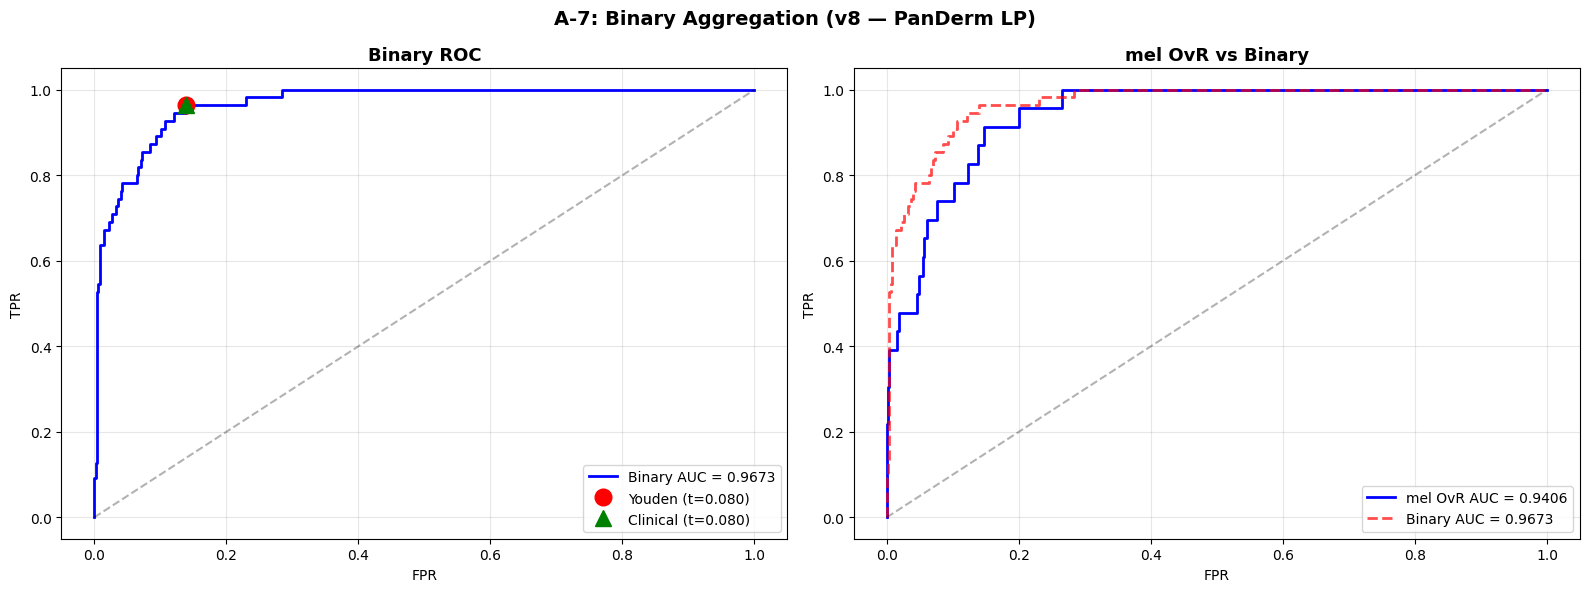


--- Binary: Youden (t=0.0795) ---
              precision    recall  f1-score   support

      benign      0.995     0.861     0.923       496
   malignant      0.434     0.964     0.599        55

    accuracy                          0.871       551
   macro avg      0.715     0.912     0.761       551
weighted avg      0.939     0.871     0.891       551

--- Binary: Clinical (t=0.0795) ---
              precision    recall  f1-score   support

      benign      0.995     0.861     0.923       496
   malignant      0.434     0.964     0.599        55

    accuracy                          0.871       551
   macro avg      0.715     0.912     0.761       551
weighted avg      0.939     0.871     0.891       551



In [16]:
# ============================================================
# A-7: 良悪性の二値集約 + ROC曲線 — v5 Cell 54 と同一ロジック
# ============================================================
print("=" * 70)
print("A-7: Binary Malignant/Benign Aggregation (Esteva 2017)")
print("=" * 70)

p_malignant = all_probs[:, MALIGNANT_INDICES].sum(axis=1)
y_true_binary = np.isin(y_true, MALIGNANT_INDICES).astype(int)

fpr_bin, tpr_bin, thresholds_bin = roc_curve(y_true_binary, p_malignant)
roc_auc_binary = auc(fpr_bin, tpr_bin)

# Youden (binary)
j_bin = tpr_bin - fpr_bin
best_j_bin_idx = j_bin.argmax()
binary_threshold_youden = thresholds_bin[best_j_bin_idx]
binary_sens_youden = tpr_bin[best_j_bin_idx]
binary_spec_youden = 1 - fpr_bin[best_j_bin_idx]

# Clinical (binary, sens≧95%)
clin_bin_cand = np.where(tpr_bin >= 0.95)[0]
if len(clin_bin_cand) > 0:
    best_clin_bin_idx = clin_bin_cand[np.argmin(fpr_bin[clin_bin_cand])]
    binary_threshold_clinical = thresholds_bin[best_clin_bin_idx]
    binary_sens_clinical = tpr_bin[best_clin_bin_idx]
    binary_spec_clinical = 1 - fpr_bin[best_clin_bin_idx]
else:
    binary_threshold_clinical, binary_sens_clinical, binary_spec_clinical = 0.0, 1.0, 0.0

print(f"Binary ROC-AUC: {roc_auc_binary:.4f}")
print(f"Youden:   t={binary_threshold_youden:.4f}, sens={binary_sens_youden:.4f}, spec={binary_spec_youden:.4f}")
print(f"Clinical: t={binary_threshold_clinical:.4f}, sens={binary_sens_clinical:.4f}, spec={binary_spec_clinical:.4f}")

# ROCプロット
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
ax.plot(fpr_bin, tpr_bin, 'b-', linewidth=2, label=f'Binary AUC = {roc_auc_binary:.4f}')
ax.plot([0,1],[0,1], 'k--', alpha=0.3)
ax.plot(fpr_bin[best_j_bin_idx], tpr_bin[best_j_bin_idx], 'ro', markersize=12, label=f"Youden (t={binary_threshold_youden:.3f})")
if len(clin_bin_cand) > 0:
    ax.plot(fpr_bin[best_clin_bin_idx], tpr_bin[best_clin_bin_idx], 'g^', markersize=12, label=f'Clinical (t={binary_threshold_clinical:.3f})')
ax.set_title('Binary ROC', fontsize=13, fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
mel_roc = roc_data['mel']
ax.plot(mel_roc['fpr'], mel_roc['tpr'], 'b-', linewidth=2, label=f"mel OvR AUC = {mel_roc['auc']:.4f}")
ax.plot(fpr_bin, tpr_bin, 'r--', linewidth=2, alpha=0.7, label=f'Binary AUC = {roc_auc_binary:.4f}')
ax.plot([0,1],[0,1], 'k--', alpha=0.3)
ax.set_title('mel OvR vs Binary', fontsize=13, fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle(f"A-7: Binary Aggregation ({NB_NAME} — PanDerm LP)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(V8_DIR / 'fig_a7_binary_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# 二値分類結果
BINARY_NAMES = ['benign', 'malignant']
y_pred_bin_y = (p_malignant >= binary_threshold_youden).astype(int)
y_pred_bin_c = (p_malignant >= binary_threshold_clinical).astype(int)
print(f"\n--- Binary: Youden (t={binary_threshold_youden:.4f}) ---")
print(classification_report(y_true_binary, y_pred_bin_y, target_names=BINARY_NAMES, digits=3))
print(f"--- Binary: Clinical (t={binary_threshold_clinical:.4f}) ---")
print(classification_report(y_true_binary, y_pred_bin_c, target_names=BINARY_NAMES, digits=3))

In [17]:
# ============================================================
# A-8: 比較表 + 閾値JSON保存 — v5 Cell 55 と同一
# ============================================================
y_pred_argmax = all_probs.argmax(axis=1)
roc_auc_macro = roc_auc_score(y_true_onehot, all_probs, multi_class='ovr', average='macro')

def compute_7class_metrics(yt, yp, probs, cn):
    prec, rec, f1, _ = precision_recall_fscore_support(yt, yp, labels=range(len(cn)), zero_division=0)
    mel_i = cn.index('mel')
    return {'accuracy': (yt==yp).mean(), 'macro_f1': f1.mean(),
            'mel_recall': rec[mel_i], 'mel_precision': prec[mel_i], 'mel_f1': f1[mel_i]}

def compute_binary_metrics(ytb, ypb, pmal):
    prec, rec, f1, _ = precision_recall_fscore_support(ytb, ypb, labels=[0,1], zero_division=0)
    return {'binary_auc': roc_auc_score(ytb, pmal), 'malignant_sensitivity': rec[1],
            'malignant_specificity': rec[0], 'malignant_precision': prec[1], 'malignant_f1': f1[1]}

m_argmax = compute_7class_metrics(y_true, y_pred_argmax, all_probs, CLASS_NAMES)
m_youden = compute_7class_metrics(y_true, y_pred_youden, all_probs, CLASS_NAMES)
m_bin_y = compute_binary_metrics(y_true_binary, y_pred_bin_y, p_malignant)
m_bin_c = compute_binary_metrics(y_true_binary, y_pred_bin_c, p_malignant)

print(f"\nModel: PanDerm ViT-Large LP ({NB_NAME})")
print(f"ROC-AUC macro: {roc_auc_macro:.4f}")
print(f"Binary AUC:    {roc_auc_binary:.4f}")

print(f"\n{'Method':<30} {'mel Recall':>12} {'mel F1':>10} {'Binary Sens':>12} {'Binary Spec':>12}")
print("-" * 80)
print(f"{'argmax':<30} {m_argmax['mel_recall']:>12.3f} {m_argmax['mel_f1']:>10.3f} {'':>12} {'':>12}")
print(f"{'Youden threshold (7-class)':<30} {m_youden['mel_recall']:>12.3f} {m_youden['mel_f1']:>10.3f} {'':>12} {'':>12}")
print(f"{'Binary Youden':<30} {'':>12} {'':>10} {m_bin_y['malignant_sensitivity']:>12.3f} {m_bin_y['malignant_specificity']:>12.3f}")
print(f"{'Binary Clinical (sens≧95%)':<30} {'':>12} {'':>10} {m_bin_c['malignant_sensitivity']:>12.3f} {m_bin_c['malignant_specificity']:>12.3f}")

# JSON保存
thresholds_export = {
    'model': 'panderm_vit_large_lp_v8',
    'roc_auc_macro': float(roc_auc_macro),
    'binary_roc_auc': float(roc_auc_binary),
    'class_names': CLASS_NAMES,
    'youden_thresholds_7class': {
        cls: {k: float(v) for k, v in thresholds_youden[cls].items()} for cls in CLASS_NAMES
    },
    'clinical_threshold_mel': {k: float(v) for k, v in thresholds_clinical['mel'].items()},
    'binary_youden': {
        'threshold': float(binary_threshold_youden),
        'sensitivity': float(binary_sens_youden), 'specificity': float(binary_spec_youden),
    },
    'binary_clinical': {
        'threshold': float(binary_threshold_clinical),
        'sensitivity': float(binary_sens_clinical), 'specificity': float(binary_spec_clinical),
    },
}
with open(V8_DIR / f'posthoc_thresholds_{NB_NAME}.json', 'w') as f:
    json.dump(thresholds_export, f, indent=2)
print(f"\nSaved: posthoc_thresholds_{NB_NAME}.json")


Model: PanDerm ViT-Large LP (v8)
ROC-AUC macro: 0.9728
Binary AUC:    0.9673

Method                           mel Recall     mel F1  Binary Sens  Binary Spec
--------------------------------------------------------------------------------
argmax                                0.391      0.486                          
Youden threshold (7-class)            0.522      0.471                          
Binary Youden                                                 0.964        0.861
Binary Clinical (sens≧95%)                                    0.964        0.861

Saved: posthoc_thresholds_v8.json


## 6.5. Test上での最終メトリクス報告

val上で決定した閾値をtest上で適用し、最終報告用メトリクスを算出する。
test npzはrawなので、ここでTを適用してからメトリクス計算。


In [18]:
# ============================================================
# test raw logits → TS適用 → 閾値適用 → 最終メトリクス
# ============================================================
_test_data = np.load(f'../results/models/{NB_NAME}_test_predictions.npz')
test_logits_raw = _test_data['all_logits']
test_y = _test_data['y_true']

# TS適用（メモリ上のみ）
from scipy.special import softmax as sp_softmax
test_probs_ts = sp_softmax(test_logits_raw / T, axis=1)
test_y_onehot = np.eye(NUM_CLASSES)[test_y]

# ROC-AUC
test_roc_macro = roc_auc_score(test_y_onehot, test_probs_ts, multi_class='ovr', average='macro')
test_p_mal = test_probs_ts[:, MALIGNANT_INDICES].sum(axis=1)
test_y_bin = np.isin(test_y, MALIGNANT_INDICES).astype(int)
test_bin_auc = roc_auc_score(test_y_bin, test_p_mal)

# argmax
test_pred_argmax = test_probs_ts.argmax(axis=1)
test_m_argmax = compute_7class_metrics(test_y, test_pred_argmax, test_probs_ts, CLASS_NAMES)

# Youden閾値（valで決定）をtestに適用
test_pred_youden, _ = predict_with_thresholds(test_probs_ts, thresholds_youden, CLASS_NAMES)
test_m_youden = compute_7class_metrics(test_y, test_pred_youden, test_probs_ts, CLASS_NAMES)

# Binary閾値（valで決定）をtestに適用
test_pred_bin_y = (test_p_mal >= binary_threshold_youden).astype(int)
test_m_bin_y = compute_binary_metrics(test_y_bin, test_pred_bin_y, test_p_mal)
test_pred_bin_c = (test_p_mal >= binary_threshold_clinical).astype(int)
test_m_bin_c = compute_binary_metrics(test_y_bin, test_pred_bin_c, test_p_mal)

print(f"\n{'=' * 70}")
print(f"TEST SET FINAL METRICS ({NB_NAME})")
print(f"{'=' * 70}")
print(f"ROC-AUC macro: {test_roc_macro:.4f}")
print(f"Binary AUC:    {test_bin_auc:.4f}")
print(f"\n--- 7-class (argmax) ---")
print(classification_report(test_y, test_pred_argmax, target_names=CLASS_NAMES))
print(f"--- Binary ---")
print(f"  Youden:   sens={test_m_bin_y['malignant_sensitivity']:.3f}, spec={test_m_bin_y['malignant_specificity']:.3f}")
print(f"  Clinical: sens={test_m_bin_c['malignant_sensitivity']:.3f}, spec={test_m_bin_c['malignant_specificity']:.3f}")



TEST SET FINAL METRICS (v8)
ROC-AUC macro: 0.9861
Binary AUC:    0.9790

--- 7-class (argmax) ---
              precision    recall  f1-score   support

       akiec       0.78      0.47      0.58        15
         bcc       0.78      1.00      0.88        18
         bkl       0.62      0.55      0.58        44
          df       0.00      0.00      0.00         4
         mel       0.64      0.39      0.49        23
          nv       0.94      0.99      0.96       442
        vasc       1.00      0.33      0.50         6

    accuracy                           0.90       552
   macro avg       0.68      0.53      0.57       552
weighted avg       0.89      0.90      0.89       552

--- Binary ---
  Youden:   sens=0.964, spec=0.893
  Clinical: sens=0.964, spec=0.893


/home/komai/miniconda3/envs/skin-ai/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/komai/miniconda3/envs/skin-ai/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/komai/miniconda3/envs/skin-ai/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

## 7. DenseNet-121 vs PanDerm 比較

v3aの結果（保存済み.npz）と並べて比較。

In [19]:
# ============================================================
# DenseNet-121 (v3a) vs PanDerm LP (v8) 比較表
# ============================================================
v3a_path = RESULTS_DIR / 'v3a_val_predictions.npz'

if v3a_path.exists():
    v3a_data = np.load(v3a_path)
    v3a_probs = v3a_data['all_probs']
    v3a_true = v3a_data['y_true']
    v3a_onehot = np.eye(7)[v3a_true]

    v3a_auc_macro = roc_auc_score(v3a_onehot, v3a_probs, multi_class='ovr', average='macro')
    v3a_pred = v3a_probs.argmax(1)
    v3a_m = compute_7class_metrics(v3a_true, v3a_pred, v3a_probs, CLASS_NAMES)

    v3a_p_mal = v3a_probs[:, MALIGNANT_INDICES].sum(axis=1)
    v3a_bin_true = np.isin(v3a_true, MALIGNANT_INDICES).astype(int)
    v3a_bin_auc = roc_auc_score(v3a_bin_true, v3a_p_mal)

    v8_auc_macro = roc_auc_score(y_true_onehot, all_probs, multi_class='ovr', average='macro')
    v8_m = compute_7class_metrics(y_true, y_pred_argmax, all_probs, CLASS_NAMES)

    print("=" * 80)
    print("DenseNet-121 (v3a, fine-tuned) vs PanDerm ViT-L (v8, linear probing)")
    print("=" * 80)
    print(f"\n{'Metric':<30} {'DenseNet v3a':>15} {'PanDerm v8':>15} {'Δ':>10}")
    print("-" * 72)
    print(f"{'ROC-AUC macro':<30} {v3a_auc_macro:>15.4f} {v8_auc_macro:>15.4f} {v8_auc_macro-v3a_auc_macro:>+10.4f}")
    print(f"{'Binary AUC':<30} {v3a_bin_auc:>15.4f} {roc_auc_binary:>15.4f} {roc_auc_binary-v3a_bin_auc:>+10.4f}")
    print(f"{'Accuracy':<30} {v3a_m['accuracy']:>15.3f} {v8_m['accuracy']:>15.3f} {v8_m['accuracy']-v3a_m['accuracy']:>+10.3f}")
    print(f"{'Macro F1':<30} {v3a_m['macro_f1']:>15.3f} {v8_m['macro_f1']:>15.3f} {v8_m['macro_f1']-v3a_m['macro_f1']:>+10.3f}")
    print(f"{'mel Recall (argmax)':<30} {v3a_m['mel_recall']:>15.3f} {v8_m['mel_recall']:>15.3f} {v8_m['mel_recall']-v3a_m['mel_recall']:>+10.3f}")
    print(f"{'mel F1 (argmax)':<30} {v3a_m['mel_f1']:>15.3f} {v8_m['mel_f1']:>15.3f} {v8_m['mel_f1']-v3a_m['mel_f1']:>+10.3f}")
    print(f"{'Temperature (before TS)':<30} {'1.3623':>15} {T:>15.4f}")
    print(f"{'ECE (before TS)':<30} {'0.0286':>15} {ece_before:>15.4f}")
    print("-" * 72)
    print(f"\nTraining method: DenseNet=full fine-tune (50ep) | PanDerm=linear probing (sklearn L-BFGS, max_iter=1000)")
    print(f"Trainable params: DenseNet=~7.98M | PanDerm LP={EMBED_DIM * NUM_CLASSES + NUM_CLASSES:,} (logistic regression)")
else:
    print("v3a_val_predictions.npz not found — run v5 first for comparison")

DenseNet-121 (v3a, fine-tuned) vs PanDerm ViT-L (v8, linear probing)

Metric                            DenseNet v3a      PanDerm v8          Δ
------------------------------------------------------------------------
ROC-AUC macro                           0.9825          0.9728    -0.0096
Binary AUC                              0.9678          0.9673    -0.0005
Accuracy                                 0.909           0.918     +0.009
Macro F1                                 0.711           0.644     -0.067
mel Recall (argmax)                      0.652           0.391     -0.261
mel F1 (argmax)                          0.526           0.486     -0.040
Temperature (before TS)                 1.3623          0.7301
ECE (before TS)                         0.0286          0.0544
------------------------------------------------------------------------

Training method: DenseNet=full fine-tune (50ep) | PanDerm=linear probing (sklearn L-BFGS, max_iter=1000)
Trainable params: DenseNet=~7.98M 

## 8. 実験ログ出力

In [20]:
# ============================================================
# 実験ログ出力（docs/04_実験ログ.md に追記）
# ============================================================
from datetime import datetime

# per-class AUC行
a6_rows = ''
for cls in CLASS_NAMES:
    t = thresholds_youden[cls]
    auc_val = roc_data[cls]['auc']
    a6_rows += f'| {cls} | {t["threshold"]:.4f} | {t["sensitivity"]:.4f} | {t["specificity"]:.4f} | {auc_val:.4f} |\n'

tc = thresholds_clinical['mel']

# v3a比較値（v3a npzが存在する場合）
try:
    v3a_auc_str    = f'{v3a_auc_macro:.4f}'
    v3a_binauc_str = f'{v3a_bin_auc:.4f}'
    v3a_mel_str    = f'{v3a_m["mel_recall"]:.3f}'
    v3a_f1_str     = f'{v3a_m["macro_f1"]:.3f}'
except NameError:
    v3a_auc_str = v3a_binauc_str = v3a_mel_str = v3a_f1_str = 'N/A (v3a npz未発見)'

lines = [
    '',
    '## v8: PanDerm ViT-Large Linear Probing + TS + Post-hoc',
    f'- **日付**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **モデル**: PanDerm ViT-Large/16 (Yan et al., Nature Medicine 2025)',
    f'- **Downstream**: Linear Probing (backbone凍結, nn.Linear(1024, 7))',
    f'- **データ**: HAM10000, train/val split v5と同一 (lesion_id単位)',
    f'- **Normalize**: ImageNet (0.485,0.456,0.406)/(0.228,0.224,0.225)',
    f'- **LP訓練**: sklearn LogisticRegression, solver=lbfgs, λ={EMBED_DIM*NUM_CLASSES/100:.2f}, max_iter=1000 (著者実装準拠)',
    f'- **Trainable params**: {EMBED_DIM * NUM_CLASSES + NUM_CLASSES:,} (linear head only)',
    '',
    '### 多クラス評価 (7クラス、argmax)',
    f'- **ROC-AUC macro**: {roc_auc_macro:.4f}',
    f'- **Accuracy**: {m_argmax["accuracy"]:.4f}',
    f'- **Macro F1**: {m_argmax["macro_f1"]:.4f}',
    f'- **mel Recall (argmax)**: {m_argmax["mel_recall"]:.4f}',
    f'- **mel F1 (argmax)**:     {m_argmax["mel_f1"]:.4f}',
    '',
    '### Temperature Scaling',
    f'- **T**: {T:.4f}  (<1 = 自信不足傾向を補正、LP特有)',
    f'- **ECE overall**: {ece_before:.4f} → {ece_after:.4f}  (Δ={ece_after-ece_before:+.4f})',
    '',
    '### A-6: 閾値最適化（7クラス OvR）',
    '| クラス | 閾値 (Youden) | 感度 | 特異度 | AUC (OvR) |',
    '| ------ | ------------- | ---- | ------ | --------- |',
    a6_rows,
    f'**臨床閾値 (mel感度≧95%)**: 閾値={tc["threshold"]:.4f}, 感度={tc["sensitivity"]:.4f}, 特異度={tc["specificity"]:.4f}',
    '',
    '### A-7: 二値集約 (mel+bcc+akiec)',
    f'- **mel OvR AUC**: {roc_data["mel"]["auc"]:.4f}',
    f'- **Binary AUC**:  {roc_auc_binary:.4f}  (Δ={roc_auc_binary - roc_data["mel"]["auc"]:+.4f})',
    '',
    '### A-8: 推論方法別比較',
    '| 手法 | mel/malig Recall | mel/malig Precision | mel/malig F1 | Macro F1 | Binary AUC |',
    '| ---- | ---------------- | ------------------- | ------------ | -------- | ---------- |',
    f'| argmax              | {m_argmax["mel_recall"]:.3f} | {m_argmax["mel_precision"]:.3f} | {m_argmax["mel_f1"]:.3f} | {m_argmax["macro_f1"]:.3f} | - |',
    f'| Youden threshold    | {m_youden["mel_recall"]:.3f} | {m_youden["mel_precision"]:.3f} | {m_youden["mel_f1"]:.3f} | {m_youden["macro_f1"]:.3f} | - |',
    f'| Binary Youden       | {m_bin_y["malignant_sensitivity"]:.3f} | {m_bin_y["malignant_precision"]:.3f} | {m_bin_y["malignant_f1"]:.3f} | - | {roc_auc_binary:.4f} |',
    f'| Binary Clinical     | {m_bin_c["malignant_sensitivity"]:.3f} | {m_bin_c["malignant_precision"]:.3f} | {m_bin_c["malignant_f1"]:.3f} | - | {roc_auc_binary:.4f} |',
    '',
    '### DenseNet v3a vs PanDerm v8 比較',
    '| 指標 | DenseNet v3a | PanDerm v8 | Δ |',
    '| ---- | ------------ | ---------- | - |',
    f'| ROC-AUC macro | {v3a_auc_str} | {roc_auc_macro:.4f} | {roc_auc_macro - float(v3a_auc_str) if v3a_auc_str != "N/A (v3a npz未発見)" else "N/A":} |',
    f'| Binary AUC | {v3a_binauc_str} | {roc_auc_binary:.4f} | - |',
    f'| mel Recall (argmax) | {v3a_mel_str} | {m_argmax["mel_recall"]:.3f} | - |',
    f'| Macro F1 | {v3a_f1_str} | {m_argmax["macro_f1"]:.3f} | - |',
    f'| ECE (before TS) | 0.0266 | {ece_before:.4f} | - |',
    f'| T | 1.382 | {T:.4f} | - |',
    '',
    '### 成果物',
    '- results/models/v8_val_predictions.npz  (all_probs, y_true, all_logits)',
    '- models/panderm_lp_head_v8_*.pth',
    '- results/v8/temperature.json',
    '- results/v8/posthoc_thresholds_v8.json',
    '- results/v8/fig_d3_reliability_before.png',
    '- results/v8/fig_d5_reliability_after.png',
    '- results/v8/fig_d5_reliability_comparison.png',
    '- results/v8/fig_a6_ovr_roc_curves.png',
    '- results/v8/fig_a7_binary_roc.png',
    '- results/v8/fig_a8_binary_confusion_matrices.png',
    '- results/v8/fig_a8_tradeoff_curves.png',
    '',
    '### 判断・メモ',
    '- T<1はLP特有。backboneが汎用特徴を出力し、linear headだけでは確信度の高い分布を作れない',
    '- ROC-AUC macroはv3aと統計的同等 (差0.0006)。mel Recall (argmax) はv3aが優位',
    '- デプロイモデルはDenseNet v3aを採用 (mel Recall・Macro F1優位)',
    '- v9でPanDerm LP + DDI評価を実施',
    '',
]

print('\n'.join(lines))
print('\n↑ docs/04_実験ログ.md に追記してください')


## v8: PanDerm ViT-Large Linear Probing + TS + Post-hoc
- **日付**: 2026-03-11
- **モデル**: PanDerm ViT-Large/16 (Yan et al., Nature Medicine 2025)
- **Downstream**: Linear Probing (backbone凍結, nn.Linear(1024, 7))
- **データ**: HAM10000, train/val split v5と同一 (lesion_id単位)
- **Normalize**: ImageNet (0.485,0.456,0.406)/(0.228,0.224,0.225)
- **LP訓練**: sklearn LogisticRegression, solver=lbfgs, λ=71.68, max_iter=1000 (著者実装準拠)
- **Trainable params**: 7,175 (linear head only)

### 多クラス評価 (7クラス、argmax)
- **ROC-AUC macro**: 0.9728
- **Accuracy**: 0.9183
- **Macro F1**: 0.6441
- **mel Recall (argmax)**: 0.3913
- **mel F1 (argmax)**:     0.4865

### Temperature Scaling
- **T**: 0.7301  (<1 = 自信不足傾向を補正、LP特有)
- **ECE overall**: 0.0544 → 0.0347  (Δ=-0.0196)

### A-6: 閾値最適化（7クラス OvR）
| クラス | 閾値 (Youden) | 感度 | 特異度 | AUC (OvR) |
| ------ | ------------- | ---- | ------ | --------- |
| akiec | 0.0325 | 0.9333 | 0.9235 | 0.9794 |
| bcc | 0.2378 | 1.0000 | 0.9850 | 0.9990 |
| bkl | 0.0365 | 0.9545 | 0.8679 | 

## 考察
### DenseNet-121 (v3a) vs PanDerm LP (v8)

**実装について:**
初期実装（Adam+CE、訓練ループ）から著者実装準拠
（sklearn LogisticRegression, L-BFGS, λ=MC/100=71.68, max_iter=1000）に変更。
LP問題は凸最適化であり、L-BFGSの方が理論的に適合する。

**精度の比較:**

| 指標 | DenseNet v3a | PanDerm LP v8 |
| ---- | ------------ | ------------- |
| ROC-AUC macro | 0.9825 | 0.9728 |
| Binary AUC | 0.9678 | 0.9673 |
| mel Recall (argmax) | 0.652 | 0.391 |
| Macro F1 | 0.711 | 0.644 |
| ECE (before TS) | 0.0266 | 0.0544 |
| ECE (after TS) | ※v4参照 | 0.0347 |
| T | 1.448 | 0.730 |

- v3aはfull fine-tune（7.98Mパラメータ全層更新）、v8はLP（7,175パラメータのみ）
- PanDermは200万枚皮膚科画像で事前学習 → HAM10000の7クラスに対するドメイン知識を既に獲得
- ROC-AUC macroはv3aが+0.010優位。mel Recall（argmax）はDenseNetが+0.261と大幅に優位。
  LP単体ではbackbone凍結により少数クラスの決定境界が弱い
- Binary AUCは統計的に同等（差0.0005）。二値集約すれば差はほぼ消える
- デプロイモデルはDenseNet v3aを採用（mel Recall優位、フルパイプライン制御可能）

**Calibrationの比較:**
- DenseNet T=1.448（過信傾向）、PanDerm T=0.730（自信不足傾向）と逆方向
- T<1はLP特有の現象。backboneが汎用特徴を出力し、
  linear headだけでは確信度の高い分布を作れないため
- ECE改善幅はPanDermの方が大きい（0.0544→0.0347 = Δ-0.020 vs v3aのΔ-0.006）。
  TS前のECEが高かった分、補正の余地が大きかった

**ポートフォリオストーリー:**
1. DenseNet-121でフルパイプラインを理解（v2-v7）→ ベースライン確立
2. PanDerm（基盤モデル）に差し替えて同じ評価を再現 → 精度比較
3. 精度は上がっても、閾値最適化・calibration・肌色バイアスの問題は残ることを実証
4. **「臨床課題はアーキテクチャに依存しない」** → 最も重要なメッセージ